In [1]:
# Cài đặt các thư viện cần thiết[cite: 1]
!pip install -q transformers datasets evaluate seqeval underthesea

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 92.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 64.6 MB/s eta 0:00:00


In [ ]:
import json
import unicodedata
import pandas as pd
from transformers import AutoTokenizer
from underthesea import word_tokenize

# 2. Cấu hình PhoBERT[cite: 1]
model_checkpoint = "vinai/phobert-base-v2"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint, use_fast=True)
print(f'\nTokenizer fast? {tokenizer.is_fast}')
print(f'CLS={tokenizer.cls_token_id}, SEP={tokenizer.sep_token_id}')

config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Tokenizer fast? False
CLS=0, SEP=2


In [4]:
import json
from datasets import Dataset

# Cập nhật đúng đường dẫn thư mục chứa dataset trên Kaggle
data_dir = "/kaggle/input/datasets/vhutrdng/uit-visd4sa"

# Hàm đọc file JSONL
def load_jsonl(file_path):
    data = []
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            data.append(json.loads(line))
    return data

# Đọc các tệp dữ liệu
print("Đang tải dữ liệu...")
train_data = load_jsonl(f"{data_dir}/train.jsonl")
dev_data = load_jsonl(f"{data_dir}/dev.jsonl")
# Bạn có thể đọc luôn test_data nếu lát nữa muốn inference kiểm tra
# test_data = load_jsonl(f"{data_dir}/test.jsonl") 

print(f'Train: {len(train_data)} mẫu, Dev: {len(dev_data)} mẫu')

# Áp dụng Tokenize và tạo BIO tags cho từng tập
print('\nTokenizing Train data...')
train_processed = [create_bio_tags(item) for item in train_data]

print('Tokenizing Dev data...')
dev_processed = [create_bio_tags(item) for item in dev_data]

Đang tải dữ liệu...
Train: 7785 mẫu, Dev: 1112 mẫu

Tokenizing Train data...
Tokenizing Dev data...


In [8]:
# === Helper: word segmentation + align span ===[cite: 1]
# PhoBERT yêu cầu input đã được word-segmented (vd 'Màn_hình' thay vì 'Màn hình')[cite: 1]
# Sau khi segment, các char offset thay đổi → cần align lại span[cite: 1]

def vietnamese_word_segment(text):
    return word_tokenize(text, format='text')

def _build_char_map(orig, seg):
    """Map char position trong orig → char position trong seg.""" #[cite: 1]
    char_map = [-1] * len(orig)
    i, j = 0, 0
    while i < len(orig) and j < len(seg):
        if orig[i] == seg[j]:
            char_map[i] = j; i += 1; j += 1
        elif seg[j] == '_': j += 1
        elif orig[i].isspace(): i += 1
        elif seg[j].isspace(): j += 1
        else: i += 1
    return char_map

def align_spans_after_segmentation(text, labels):
    """Align (start, end) span sau khi word_segment chèn '_'.""" #[cite: 1]
    segmented = vietnamese_word_segment(text)
    char_map = _build_char_map(text, segmented)
    new_labels = []
    for start, end, lab in labels:
        new_start = -1
        for k in range(start, min(end, len(text))):
            if 0 <= k < len(char_map) and char_map[k] != -1:
                new_start = char_map[k]; break
        if new_start == -1:
            continue
        new_end = new_start + 1
        for k in range(end - 1, start - 1, -1):
            if 0 <= k < len(char_map) and char_map[k] != -1:
                new_end = char_map[k] + 1; break
        # Mở rộng đến hết multi-syllable word[cite: 1]
        while new_end < len(segmented) and segmented[new_end] == '_':
            new_end += 1
            while new_end < len(segmented) and not segmented[new_end].isspace():
                new_end += 1
        new_labels.append([new_start, new_end, lab])
    return segmented, new_labels

# === Tokenize + sinh BIO tag (không dùng offset_mapping) ===[cite: 1]
# Cách làm: tokenize từng word riêng, propagate tag về subword đầu[cite: 1]
# An toàn với cả slow tokenizer của PhoBERT trên Kaggle[cite: 1]

def get_word_offsets(text):
    """Char offset của mỗi word khi split bằng space.""" #[cite: 1]
    offsets, pos = [], 0
    for w in text.split():
        idx = text.find(w, pos)
        offsets.append((idx, idx + len(w)))
        pos = idx + len(w)
    return offsets

def create_bio_tags(example, max_length=256):
    # 1. Normalize unicode (giữ độ dài để align span)[cite: 1]
    text = unicodedata.normalize('NFC', example['text'])
    labels = example['labels']  # [[start, end, 'LABEL#SENT'], ...][cite: 1]
    
    # 2. Word segment + align span[cite: 1]
    seg, aligned_labels = align_spans_after_segmentation(text, labels)
    words = seg.split()
    word_offsets = get_word_offsets(seg)
    
    # 3. Tạo BIO ở word level[cite: 1]
    word_tags = ['O'] * len(words)
    for start_char, end_char, label_str in aligned_labels:
        first = True
        for wi, (ws, we) in enumerate(word_offsets):
            if ws < end_char and we > start_char:
                if first:
                    word_tags[wi] = f'B-{label_str}'
                    first = False
                else:
                    word_tags[wi] = f'I-{label_str}'
    
    # 4. Tokenize từng word + propagate tag[cite: 1]
    input_ids = [tokenizer.cls_token_id]
    bio_tags = ['SPECIAL']  # placeholder, sẽ thành -100 sau[cite: 1]
    attention_mask = [1]
    
    for word, tag in zip(words, word_tags):
        sub_ids = tokenizer.encode(word, add_special_tokens=False)
        if not sub_ids: continue
        if len(input_ids) + len(sub_ids) + 1 > max_length: break
        input_ids.extend(sub_ids)
        bio_tags.append(tag)  # subword đầu giữ tag[cite: 1]
        bio_tags.extend(['SPECIAL'] * (len(sub_ids) - 1))  # subword sau → ignore[cite: 1]
        attention_mask.extend([1] * len(sub_ids))
    
    input_ids.append(tokenizer.sep_token_id)
    bio_tags.append('SPECIAL')
    attention_mask.append(1)
    
    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'labels': bio_tags,
    }



In [12]:
from datasets import Dataset

# 1. Trích danh sách nhãn unique từ cả 2 tập train và dev (bỏ qua 'SPECIAL')
all_labels = set()
for item in train_processed + dev_processed:
    for lab in item['labels']:
        if lab != 'SPECIAL':
            all_labels.add(lab)
all_labels = sorted(list(all_labels))

print(f'Số nhãn unique: {len(all_labels)}')

# 2. Tạo Mapping
label2id = {label: i for i, label in enumerate(all_labels)}
id2label = {i: label for label, i in label2id.items()}

# 3. Hàm Convert tag → id, SPECIAL → -100
def map_labels_to_ids(processed_data):
    for item in processed_data:
        new_labels = []
        for lab in item['labels']:
            if lab == 'SPECIAL':
                new_labels.append(-100)
            elif isinstance(lab, int):
                new_labels.append(lab)
            else:
                new_labels.append(label2id[lab])
        item['labels'] = new_labels
    return processed_data

# Áp dụng mapping
train_processed = map_labels_to_ids(train_processed)
dev_processed = map_labels_to_ids(dev_processed)

# 4. Tạo HF Dataset riêng biệt
train_dataset = Dataset.from_list(train_processed)
dev_dataset = Dataset.from_list(dev_processed)

print(f'\nĐã tạo thành công: train_dataset ({len(train_dataset)}), dev_dataset ({len(dev_dataset)})')

Số nhãn unique: 62

Đã tạo thành công: train_dataset (7785), dev_dataset (1112)


In [16]:
from transformers import EarlyStoppingCallback, AutoModelForTokenClassification, Trainer
from datasets import Dataset
import numpy as np

print("1. Đang khôi phục lại nhãn gốc...")
train_processed = [create_bio_tags(item) for item in train_data]
dev_processed = [create_bio_tags(item) for item in dev_data]

# Tạo lại từ điển nhãn CHUẨN
all_labels = set()
for item in train_processed + dev_processed:
    for lab in item['labels']:
        if lab != 'SPECIAL':
            all_labels.add(lab)
all_labels = sorted(list(all_labels))

label2id = {label: i for i, label in enumerate(all_labels)}
id2label = {i: label for label, i in label2id.items()}
print("✓ Từ điển nhãn ĐÃ SỬA (3 nhãn đầu):", {k: id2label[k] for k in list(id2label.keys())[:3]})

print("\n2. Đang tạo tập dữ liệu...")
def create_dataset_with_ids(processed_data):
    new_data = []
    for item in processed_data:
        new_item = item.copy()
        new_labels = [-100 if lab == 'SPECIAL' else label2id[lab] for lab in item['labels']]
        new_item['labels'] = new_labels
        new_data.append(new_item)
    return Dataset.from_list(new_data)

train_dataset = create_dataset_with_ids(train_processed)
dev_dataset = create_dataset_with_ids(dev_processed)

print("\n3. Khởi tạo lại mô hình với số lượng nhãn chính xác...")
model = AutoModelForTokenClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(all_labels),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True # Bỏ qua cảnh báo nếu trước đó model bị khởi tạo sai
)

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)
    
    true_predictions = []
    true_labels = []
    
    for prediction, label in zip(predictions, labels):
        pred_list = []
        label_list = []
        for pred, lab in zip(prediction, label):
            if lab != -100:
                pred_list.append(str(id2label[int(pred)]))
                label_list.append(str(id2label[int(lab)]))
                
        true_predictions.append(pred_list)
        true_labels.append(label_list)
    
    results = seqeval.compute(predictions=true_predictions, references=true_labels, zero_division=0)
    return {
        'precision': results['overall_precision'],
        'recall': results['overall_recall'],
        'f1': results['overall_f1'],
        'accuracy': results['overall_accuracy'],
    }

print("\n4. Bắt đầu quá trình huấn luyện...")
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    **{_tok_kwarg: tokenizer},
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)], 
)

trainer.train()

1. Đang khôi phục lại nhãn gốc...
✓ Từ điển nhãn ĐÃ SỬA (3 nhãn đầu): {0: 'B-BATTERY#NEGATIVE', 1: 'B-BATTERY#NEUTRAL', 2: 'B-BATTERY#POSITIVE'}

2. Đang tạo tập dữ liệu...

3. Khởi tạo lại mô hình với số lượng nhãn chính xác...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForTokenClassification LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.weight               | MISSING    | 
classifier.bias                 | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



4. Bắt đầu quá trình huấn luyện...


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,4.918120,4.139182,0.233317,0.269024,0.249901,0.571765
2,3.153389,2.891223,0.395680,0.471570,0.430305,0.675444
3,2.316251,2.403091,0.430609,0.503819,0.464346,0.714699
4,1.836343,2.249108,0.428471,0.517680,0.468870,0.720462
5,1.540778,2.105365,0.422060,0.523904,0.467500,0.736097
6,1.249264,2.130941,0.433715,0.524752,0.474910,0.735477
7,1.171847,2.133412,0.439645,0.532673,0.481709,0.733332
8,1.096852,2.123140,0.440139,0.536634,0.483620,0.732530
9,0.996288,2.149671,0.434544,0.538048,0.480789,0.734830
10,0.971408,2.148949,0.439114,0.538614,0.483801,0.735942


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=2440, training_loss=2.071612311191246, metrics={'train_runtime': 1155.3309, 'train_samples_per_second': 67.383, 'train_steps_per_second': 2.112, 'total_flos': 4278630108356004.0, 'train_loss': 2.071612311191246, 'epoch': 10.0})

1. Đang tải và xử lý tập Test...
✓ Đã tải xong tập Test với 2225 mẫu.

2. Đang đánh giá mô hình trên tập Test...


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]



3. Đang xuất bảng số liệu báo cáo...

📊 BẢNG TỔNG HỢP KẾT QUẢ TRÊN TẬP TEST

| Chỉ số Đánh giá (Metric)   |   Kết quả (%) |
|:---------------------------|--------------:|
| Accuracy (Độ chính xác)    |         73.94 |
| Precision (Độ chuẩn xác)   |         44.36 |
| Recall (Độ bao phủ)        |         55.87 |
| F1-Score                   |         49.45 |



/tmp/ipykernel_58/2051997982.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Chỉ số Đánh giá (Metric)", y="Kết quả (%)", data=df_metrics, palette="viridis")


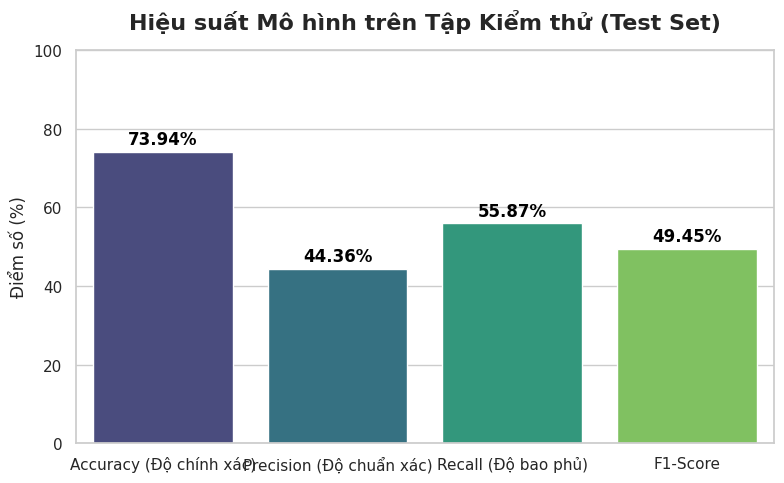


✅ Đã lưu ảnh biểu đồ báo cáo cực nét tại: /kaggle/working/test_metrics_report.png


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("1. Đang tải và xử lý tập Test...")
# Đọc file test (Kế thừa các hàm từ các cell trước)
test_data = load_jsonl(f"{data_dir}/test.jsonl")
test_processed = [create_bio_tags(item) for item in test_data]
test_dataset = create_dataset_with_ids(test_processed)

print(f"✓ Đã tải xong tập Test với {len(test_dataset)} mẫu.")

print("\n2. Đang đánh giá mô hình trên tập Test...")
# Hàm predict() tự động tính toán các metrics thông qua compute_metrics
test_predictions, test_labels, test_metrics = trainer.predict(test_dataset)

print("\n3. Đang xuất bảng số liệu báo cáo...")
# Trích xuất các chỉ số và quy đổi sang thang điểm 100%
# Lưu ý: Khi dùng trainer.predict(), các key sẽ có tiền tố 'test_'
metrics_dict = {
    "Chỉ số Đánh giá (Metric)": ["Accuracy (Độ chính xác)", "Precision (Độ chuẩn xác)", "Recall (Độ bao phủ)", "F1-Score"],
    "Kết quả (%)": [
        round(test_metrics['test_accuracy'] * 100, 2),
        round(test_metrics['test_precision'] * 100, 2),
        round(test_metrics['test_recall'] * 100, 2),
        round(test_metrics['test_f1'] * 100, 2)
    ]
}

# Tạo DataFrame Pandas
df_metrics = pd.DataFrame(metrics_dict)

# In ra màn hình dạng bảng Markdown để copy
print("\n" + "="*50)
print("📊 BẢNG TỔNG HỢP KẾT QUẢ TRÊN TẬP TEST")
print("="*50 + "\n")
print(df_metrics.to_markdown(index=False))
print("\n" + "="*50)

# --- VẼ BIỂU ĐỒ CỘT ĐỂ ĐƯA VÀO BÁO CÁO ---
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Vẽ biểu đồ barplot
ax = sns.barplot(x="Chỉ số Đánh giá (Metric)", y="Kết quả (%)", data=df_metrics, palette="viridis")
plt.title("Hiệu suất Mô hình trên Tập Kiểm thử (Test Set)", fontsize=16, fontweight='bold', pad=15)
plt.ylim(0, 100) # Đặt trục Y tối đa là 100%
plt.ylabel("Điểm số (%)", fontsize=12)
plt.xlabel("") # Ẩn tên trục X cho đỡ rối

# Thêm số liệu phần trăm trực tiếp lên từng cột
for index, row in df_metrics.iterrows():
    plt.text(index, row['Kết quả (%)'] + 2, f"{row['Kết quả (%)']}%", 
             color='black', ha="center", fontweight='bold', fontsize=12)

plt.tight_layout()
report_img_path = "/kaggle/working/test_metrics_report.png"
plt.savefig(report_img_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Đã lưu ảnh biểu đồ báo cáo cực nét tại: {report_img_path}")

Đang tổng hợp dữ liệu và vẽ biểu đồ...


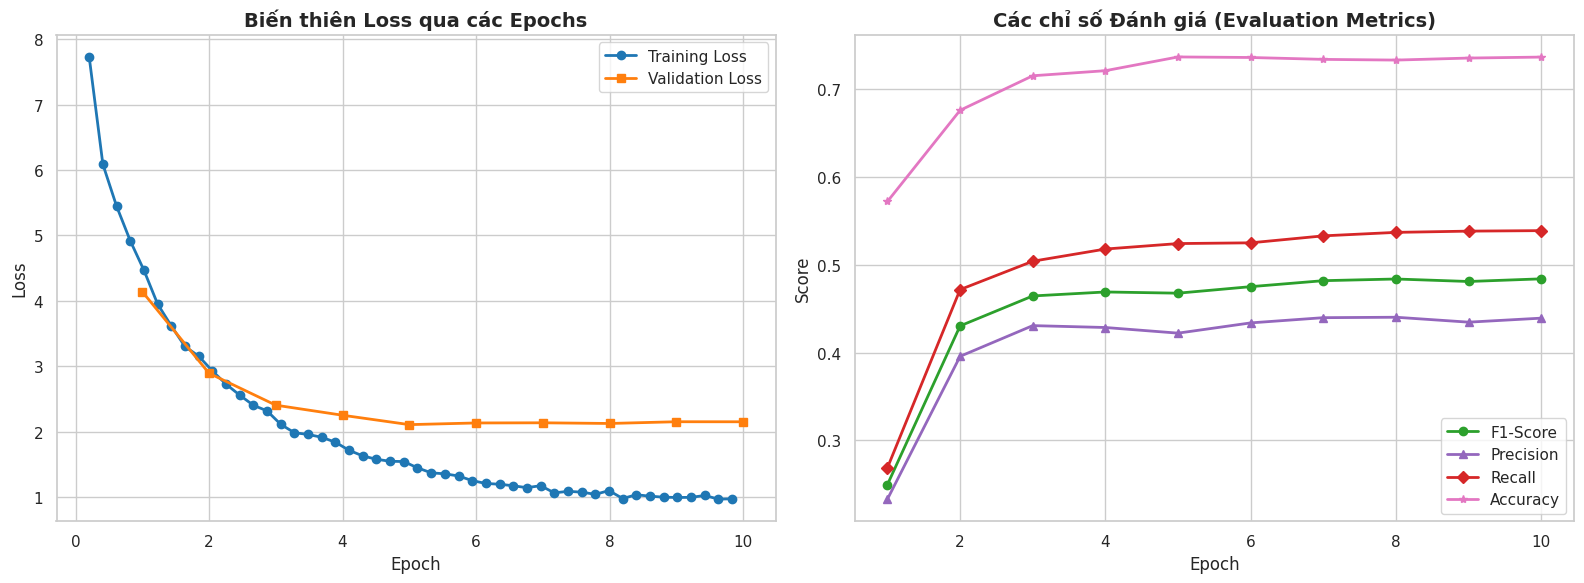

Đang chạy dự đoán trên tập Dev để vẽ Confusion Matrix...


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


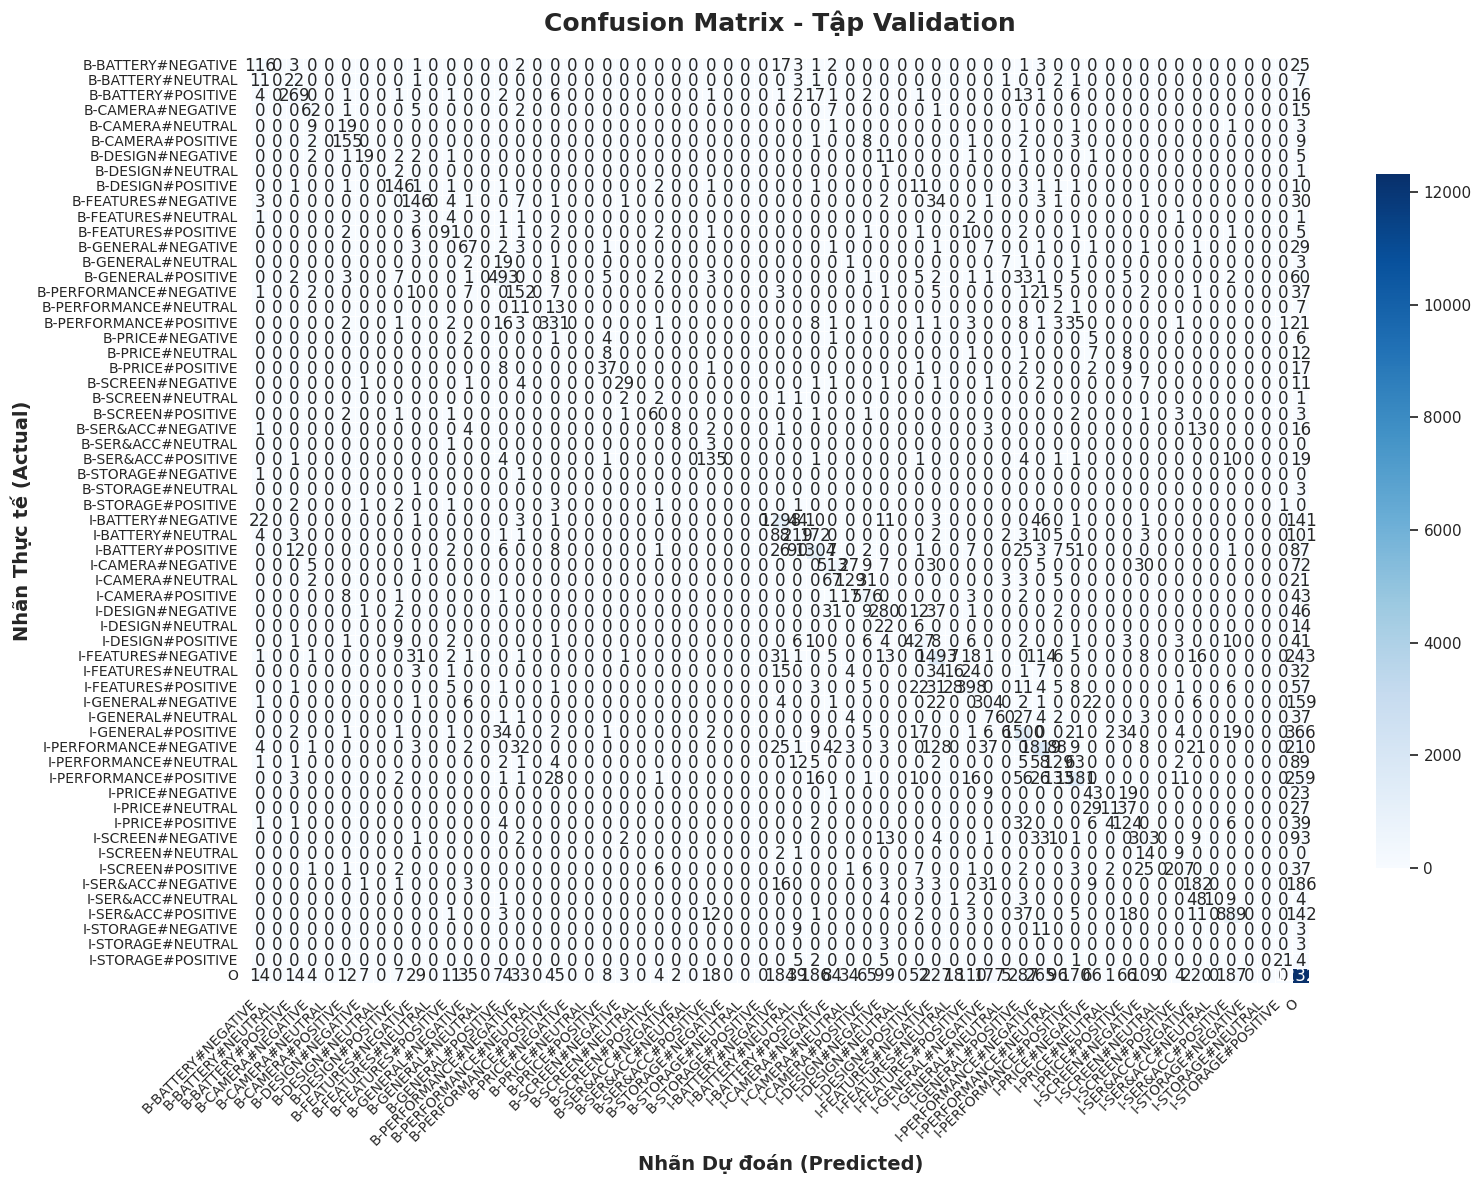

✅ Đã lưu ảnh tại:
- /kaggle/working/training_metrics.png
- /kaggle/working/confusion_matrix.png


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("Đang tổng hợp dữ liệu và vẽ biểu đồ...")

# Thiết lập style
sns.set_theme(style="whitegrid")
history = trainer.state.log_history

# 1. TRÍCH XUẤT LỊCH SỬ HUẤN LUYỆN
epochs_train, train_loss = [], []
epochs_eval, eval_loss = [], []
eval_f1, eval_precision, eval_recall, eval_accuracy = [], [], [], [] # Đã thêm eval_accuracy

for log in history:
    if 'loss' in log and 'epoch' in log:
        epochs_train.append(log['epoch'])
        train_loss.append(log['loss'])
    elif 'eval_loss' in log and 'epoch' in log:
        epochs_eval.append(log['epoch'])
        eval_loss.append(log['eval_loss'])
        eval_f1.append(log['eval_f1'])
        eval_precision.append(log['eval_precision'])
        eval_recall.append(log['eval_recall'])
        eval_accuracy.append(log['eval_accuracy']) # Lấy dữ liệu Accuracy

# --- VẼ FIGURE 1: LOSS VÀ METRICS ---
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Cột 1: Loss
ax1.plot(epochs_train, train_loss, label='Training Loss', marker='o', color='#1f77b4', linewidth=2)
if eval_loss:
    ax1.plot(epochs_eval, eval_loss, label='Validation Loss', marker='s', color='#ff7f0e', linewidth=2)
ax1.set_title('Biến thiên Loss qua các Epochs', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend()

# Cột 2: F1, Precision, Recall, Accuracy
if eval_f1:
    ax2.plot(epochs_eval, eval_f1, label='F1-Score', marker='o', color='#2ca02c', linewidth=2)
    ax2.plot(epochs_eval, eval_precision, label='Precision', marker='^', color='#9467bd', linewidth=2)
    ax2.plot(epochs_eval, eval_recall, label='Recall', marker='D', color='#d62728', linewidth=2)
    ax2.plot(epochs_eval, eval_accuracy, label='Accuracy', marker='*', color='#e377c2', linewidth=2) # Vẽ đường Accuracy

ax2.set_title('Các chỉ số Đánh giá (Evaluation Metrics)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Score', fontsize=12)
ax2.legend()

fig1.tight_layout()
metrics_path = "/kaggle/working/training_metrics.png"
fig1.savefig(metrics_path, dpi=300, bbox_inches='tight')
plt.show()

# --- VẼ FIGURE 2: CONFUSION MATRIX ---
print("Đang chạy dự đoán trên tập Dev để vẽ Confusion Matrix...")
predictions, labels, _ = trainer.predict(dev_dataset)
preds = np.argmax(predictions, axis=-1)

true_labels_flat, pred_labels_flat = [], []

for i in range(labels.shape[0]):
    for j in range(labels.shape[1]):
        if labels[i, j] != -100:
            true_labels_flat.append(id2label[labels[i, j]])
            pred_labels_flat.append(id2label[preds[i, j]])

unique_labels = sorted(list(set(true_labels_flat + pred_labels_flat)))
cm = confusion_matrix(true_labels_flat, pred_labels_flat, labels=unique_labels)

fig2 = plt.figure(figsize=(16, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=unique_labels, yticklabels=unique_labels,
            linewidths=.5, cbar_kws={"shrink": .75})

plt.title('Confusion Matrix - Tập Validation', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Nhãn Dự đoán (Predicted)', fontsize=14, fontweight='bold')
plt.ylabel('Nhãn Thực tế (Actual)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

fig2.tight_layout()
cm_path = "/kaggle/working/confusion_matrix.png"
fig2.savefig(cm_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Đã lưu ảnh tại:\n- {metrics_path}\n- {cm_path}")

In [18]:
import torch
import os

# Đường dẫn lưu file .pt
pt_model_path = "/kaggle/working/phobert_absa_model.pt"

# Trích xuất state_dict (toàn bộ trọng số) từ mô hình hiện tại
model_state_dict = model.state_dict()

# Lưu thành 1 file .pt duy nhất
torch.save(model_state_dict, pt_model_path)

print(f"✅ Đã tổng hợp và lưu trọng số mô hình thành công tại: {pt_model_path}")
print(f"Kích thước file: {os.path.getsize(pt_model_path) / (1024*1024):.2f} MB")

✅ Đã tổng hợp và lưu trọng số mô hình thành công tại: /kaggle/working/phobert_absa_model.pt
Kích thước file: 512.98 MB


In [22]:
# === Lưu checkpoint cuối ===[cite: 1]
import os
FINAL_DIR = '/kaggle/working/absa-phobert-best'
trainer.save_model(FINAL_DIR)
tokenizer.save_pretrained(FINAL_DIR)
print(f'✓ Saved best model to {FINAL_DIR}')

# === Inference với PhoBERT ===[cite: 1]
# Khác XLM-R: phải word_segment trước khi tokenize[cite: 1]
from transformers import pipeline, AutoTokenizer, AutoModelForTokenClassification
from transformers.trainer_utils import get_last_checkpoint

# 1. Tìm checkpoint[cite: 1]
model_dir = '/kaggle/working/absa-phobert-model'
model_path = get_last_checkpoint(model_dir)
if model_path is None:
    model_path = FINAL_DIR
print(f'Loading model from: {model_path}')

# 2. Load[cite: 1]
inf_tokenizer = AutoTokenizer.from_pretrained(model_path)
inf_model = AutoModelForTokenClassification.from_pretrained(model_path)

# 3. Khởi tạo pipeline[cite: 1]
absa_pipeline = pipeline(
    'token-classification',
    model=inf_model,
    tokenizer=inf_tokenizer,
    aggregation_strategy='simple',
)

# 4. Test sentences[cite: 1]
test_sentences = [
    'Màn hình hiển thị rất sắc nét, nhưng pin thì tụt quá nhanh.',
    'Nhân viên tư vấn nhiệt tình, giá cả cũng phải chăng.',
    'Máy xài chán lắm, hay bị đơ cứng ngắc.',
]

def print_absa_results(sentences):
    for i, text in enumerate(sentences):
        print(f"\n[{i+1}] Câu gốc: '{text}'")
        
        # !!! Quan trọng !!! Word segment trước khi predict[cite: 1]
        segmented = vietnamese_word_segment(text)
        print(f"     Segmented: '{segmented}'")
        
        predictions = absa_pipeline(segmented)
        
        if not predictions:
            print('  -> Không phát hiện khía cạnh nào.')
            continue
        
        print('  -> Kết quả phân tích:')
        for pred in predictions:
            label = pred['entity_group']
            word = pred['word'].replace('@@', '').replace('_', ' ')  # PhoBERT BPE[cite: 1]
            
            if '#' in label:
                aspect, sentiment = label.split('#')
                emo = '🟢' if sentiment.upper() == 'POSITIVE' else '🔴' if sentiment.upper() == 'NEGATIVE' else '⚪'
                print(f"     • Từ khóa : '{word.strip()}'")
                print(f"       Aspect  : {aspect} | Sentiment: {sentiment} {emo} | Conf: {pred['score']:.2f}")
            else:
                print(f"     • Từ khóa : '{word.strip()}' | Nhãn: {label} | Conf: {pred['score']:.2f}")

print_absa_results(test_sentences)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Saved best model to /kaggle/working/absa-phobert-best
Loading model from: /kaggle/working/absa-phobert-model/checkpoint-2440


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


[1] Câu gốc: 'Màn hình hiển thị rất sắc nét, nhưng pin thì tụt quá nhanh.'
     Segmented: 'Màn_hình hiển_thị rất sắc_nét , nhưng pin thì tụt quá nhanh .'
  -> Kết quả phân tích:
     • Từ khóa : 'Màn hình hiển thị rất sắc nét'
       Aspect  : SCREEN | Sentiment: POSITIVE 🟢 | Conf: 0.73
     • Từ khóa : 'pin thì tụt quá nhanh'
       Aspect  : BATTERY | Sentiment: NEGATIVE 🔴 | Conf: 0.89

[2] Câu gốc: 'Nhân viên tư vấn nhiệt tình, giá cả cũng phải chăng.'
     Segmented: 'Nhân_viên tư_vấn nhiệt_tình , giá_cả cũng phải_chăng .'
  -> Kết quả phân tích:
     • Từ khóa : 'Nhân viên tư vấn nhiệt tình'
       Aspect  : SER&ACC | Sentiment: POSITIVE 🟢 | Conf: 0.89
     • Từ khóa : 'giá cả cũng phải chăng'
       Aspect  : PRICE | Sentiment: POSITIVE 🟢 | Conf: 0.61

[3] Câu gốc: 'Máy xài chán lắm, hay bị đơ cứng ngắc.'
     Segmented: 'Máy xài chán lắm , hay bị đơ cứng_ngắc .'
  -> Kết quả phân tích:
     • Từ khóa : 'Máy xài chán lắm'
       Aspect  : GENERAL | Sentiment: NEGATIVE 🔴 | Conf: